In [6]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
!ls "/content/drive/MyDrive"



 1000135565.jpg
'12023002023112 (1).jpg'
 12023002023112.jpg
 1694015493263543658653682540489.jpg
 20600222018_IT_CA3.pdf
'Aadhar '
 aadhar2.pdf
'archive (2).zip'
'certificate1_merged (1).pdf'
 certificate1_merged.pdf
'certificate 2 (1).pdf'
'certificate 2.pdf'
 certificate.png
'certificate syymetric crpto2 (2).pdf'
'CETIFICTAE 1.pdf'
 Classroom
'CLASS X2.pdf'
'CLASS X.pdf'
 COA_Important_Solutions_copy.pdf
'Colab Notebooks'
'Copy of archive (2) (1).zip'
'Copy of archive (2).zip'
'Coursera TJ08C98LG51E.pdf'
'doc -12023002023112_copy.pdf'
'DocScannerMar18,20249-48PM(1) (1).pdf'
'DocScannerMar18,20249-48PM(1) (2).pdf'
'DocScannerMar18,20249-48PM(1).pdf'
'Dynamics_Meriam_7ED (1).gdoc'
 Dynamics_Meriam_7ED.gdoc
 EnglishAssignment2RupsaMaji.pdf
 IMG-20220605-WA0002.jpg
 IMG-20231206-WA0003.jpg
 income.pdf
 Java
 leapGestRecog
'MERGED CERTIFICATES.pdf'
'Name Ehsan Ashrafi Sec H Roll 55.pdf'
'PAN CARD.pdf'
 PowerOfTwoMaxHeap.java.txt
'resume t.pdf'
 rupsa.docu.pdf
'Rupsa maji_12023002023112_P

In [9]:
from zipfile import ZipFile

zip_path = "/content/drive/MyDrive/archive (2).zip"   # note the space
extract_dir = "/content/drive/MyDrive/US_Accidents"

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Files extracted to:", extract_dir)


Files extracted to: /content/drive/MyDrive/US_Accidents


In [10]:
!ls "/content/drive/MyDrive/US_Accidents"


US_Accidents_March23.csv


In [2]:
import pandas as pd

# Load only essential columns + sample rows
use_cols = ["ID","Severity","Start_Time","Start_Lat","Start_Lng","Weather_Condition","Visibility(mi)","Temperature(F)"]
df = pd.read_csv("/content/drive/MyDrive/US_Accidents/US_Accidents_March23.csv",
                 usecols=use_cols,
                 nrows=500000)   # loads first 500k rows

print(df.shape)
df.head()


(500000, 8)


,ID,Severity,Start_Time,Start_Lat,Start_Lng,Temperature(F),Visibility(mi),Weather_Condition
0,A-1,3,2016-02-08 05:46:00,39.865147,-84.058723,36.9,10.0,Light Rain
1,A-2,2,2016-02-08 06:07:59,39.928059,-82.831184,37.9,10.0,Light Rain
2,A-3,2,2016-02-08 06:49:27,39.063148,-84.032608,36.0,10.0,Overcast
3,A-4,3,2016-02-08 07:23:34,39.747753,-84.205582,35.1,9.0,Mostly Cloudy
4,A-5,2,2016-02-08 07:39:07,39.627781,-84.188354,36.0,6.0,Mostly Cloudy


In [4]:
# Check missing values
df.isnull().sum()

# Drop rows with missing critical values
df = df.dropna(subset=["Weather_Condition","Start_Lat","Start_Lng"])


In [5]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'])
df['Hour'] = df['Start_Time'].dt.hour
df['Day'] = df['Start_Time'].dt.day_name()
df['Month'] = df['Start_Time'].dt.month_name()


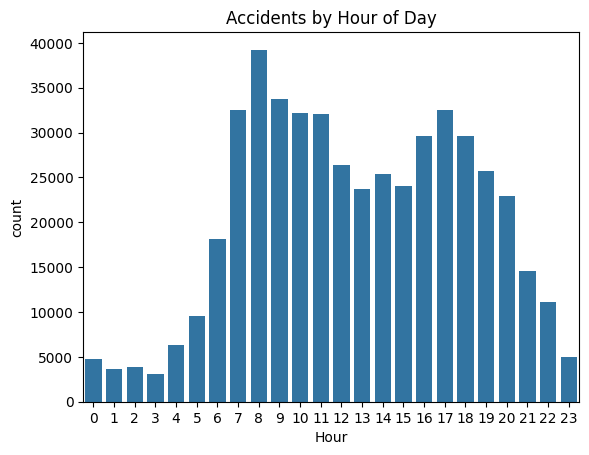

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Hour", data=df)
plt.title("Accidents by Hour of Day")
plt.show()


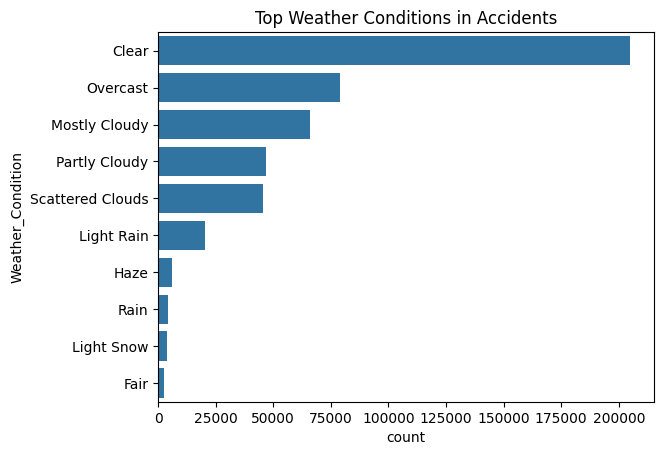

In [7]:
sns.countplot(y="Weather_Condition",
              data=df,
              order=df['Weather_Condition'].value_counts().index[:10])
plt.title("Top Weather Conditions in Accidents")
plt.show()


In [8]:
import folium

m = folium.Map(location=[37.0902, -95.7129], zoom_start=4)

for _, row in df.sample(1000).iterrows():
    folium.CircleMarker(
        location=[row['Start_Lat'], row['Start_Lng']],
        radius=2,
        color='red',
        fill=True
    ).add_to(m)

m


# Task-05: Traffic Accident Data Analysis

### Internship: ProDigy Infotech
### Dataset: US Accidents (March 2023)

## Objective
Analyze traffic accident data to identify patterns related to road conditions, weather, and time of day. Visualize accident hotspots and contributing factors.

## Key Insights
- Most accidents occur during evening rush hours.
- Rain and fog contribute to higher severity levels.
- Hotspots are concentrated in major urban areas such as Los Angeles, Dallas, and Houston.
